# Data Set Merge

Here we merge Kaggle data set with NYC/TLC data set to obtain ground truth labels i.e. taxi zone IDs for each trip sample.

In [70]:
%pip install "dask[dataframe]" pyarrow

Note: you may need to restart the kernel to use updated packages.


In [71]:
import dask.dataframe as dd

In [72]:

INPUT_CSV_PATH = './data/yellow_tripdata_2015-01.csv' # This one is from the Kaggle data set
df_csv = dd.read_csv(INPUT_CSV_PATH,  assume_missing=True) # assume_missing to avoid Dask integer assumption error
print("Loaded kaggle.csv as Dask DataFrame")

Loaded kaggle.csv as Dask DataFrame


In [73]:
print(f"kaggle.csv: {df_csv.npartitions} partitions, {len(df_csv.columns)} columns")

kaggle.csv: 31 partitions, 19 columns


In [74]:
df_csv_d = df_csv.drop_duplicates()
print("Deduplication registered.")

Deduplication registered.


In [75]:
print(f"df_csv_d partitions: {df_csv_d.npartitions}")

df_csv_d partitions: 31


In [76]:

INPUT_PARQUET_PATH = './data/yellow_tripdata_2015-01.parquet' # This one is from NYC/TLC
df_parquet = dd.read_parquet(INPUT_PARQUET_PATH)
print("Loaded nyc.parquet as Dask DataFrame")

Loaded nyc.parquet as Dask DataFrame


In [77]:
print(f"nyc.parquet: {df_parquet.npartitions} partitions, {len(df_parquet.columns)} columns")

nyc.parquet: 1 partitions, 19 columns


In [78]:
df_parquet_d = df_parquet.drop_duplicates()
print("Deduplication registered.")

Deduplication registered.


In [79]:
print(f"colnames: {df_csv_d.columns.tolist()}")

colnames: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RateCodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [80]:
print(f"colnames: {df_parquet_d.columns.tolist()}")

colnames: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [81]:
df_csv_d_d = df_csv_d.drop(columns=["VendorID", "RateCodeID","store_and_fwd_flag", "payment_type","fare_amount", "extra",
       "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge"])
print(f"colnames: {df_csv_d_d.columns}")

colnames: Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'total_amount'],
      dtype='object')


In [82]:
df_parquet_d_d = df_parquet_d.drop(columns=["VendorID", "RatecodeID","store_and_fwd_flag", "payment_type","fare_amount", "extra",
       "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "congestion_surcharge", "airport_fee","passenger_count"])
print(f"colnames: {df_parquet_d_d.columns}")
print(df_parquet_d_d.shape)

colnames: Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance',
       'PULocationID', 'DOLocationID', 'total_amount'],
      dtype='object')
(<dask_expr.expr.Scalar: expr=(Drop(frame=DropDuplicates(frame=ReadParquetFSSpec(d50751d)), columns=['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee', 'passenger_count'])).size() // 6, dtype=int32>, 6)


In [83]:
print(f"df_parquet_d_d partitions: {df_parquet_d_d.npartitions}")

df_parquet_d_d partitions: 1


In [84]:
print(f"df_csv_d_d partitions: {df_csv_d_d.npartitions}")

df_csv_d_d partitions: 31


In [85]:
composite_keys = [ "tpep_pickup_datetime", 
    "tpep_dropoff_datetime",  "total_amount" ,"trip_distance" ]

In [86]:
df_csv_d_d.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount
34,2015-01-15 19:05:43,2015-01-15 19:15:09,5.0,1.57,-73.978424,40.746208,-73.980217,40.728542,11.6
45,2015-01-25 00:13:06,2015-01-25 00:18:30,1.0,1.18,-73.983025,40.767818,-73.968307,40.763149,9.1
72,2015-01-04 13:44:54,2015-01-04 13:50:29,1.0,1.10,-73.967979,40.802135,-73.977684,40.787266,9.3
73,2015-01-04 13:44:54,2015-01-04 13:47:15,1.0,0.50,-73.962517,40.770039,-73.967735,40.762856,5.8
91,2015-01-15 14:00:45,2015-01-15 14:47:12,1.0,10.89,-74.006409,40.739765,-73.871193,40.774212,55.8


In [87]:
# Dask doesn't have .info(); dtypes are available without computing
print(df_csv_d_d.dtypes)

tpep_pickup_datetime     string[pyarrow]
tpep_dropoff_datetime    string[pyarrow]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
total_amount                     float64
dtype: object


In [88]:
print(df_parquet_d_d.dtypes)

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
trip_distance                   float64
PULocationID                      int64
DOLocationID                      int64
total_amount                    float64
dtype: object


In [89]:
df_parquet_d_d.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,total_amount
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1.0,41,166,8.40
1,2015-01-01 00:18:24,2015-01-01 00:24:20,0.9,166,238,7.30
2,2015-01-01 00:26:19,2015-01-01 00:41:06,3.5,238,162,17.40
3,2015-01-01 00:45:26,2015-01-01 00:53:20,2.1,162,263,11.87
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1.0,236,141,7.30


In [90]:
df_csv_d_d['tpep_pickup_datetime'] = dd.to_datetime(df_csv_d_d['tpep_pickup_datetime'])

In [91]:
df_csv_d_d['tpep_dropoff_datetime'] = dd.to_datetime(df_csv_d_d['tpep_dropoff_datetime'])

In [92]:
print(df_parquet_d_d.dtypes)

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
trip_distance                   float64
PULocationID                      int64
DOLocationID                      int64
total_amount                    float64
dtype: object


In [93]:

# Forcing both datetime variables to be the same type
# (because otherwise on is [us] the other is [ns], throwing error during merge)
df_csv_d_d["tpep_pickup_datetime"] = df_csv_d_d["tpep_pickup_datetime"].astype("datetime64[ns]")
df_csv_d_d["tpep_dropoff_datetime"] = df_csv_d_d["tpep_dropoff_datetime"].astype("datetime64[ns]")

df_parquet_d_d["tpep_pickup_datetime"] = df_parquet_d_d["tpep_pickup_datetime"].astype("datetime64[ns]")
df_parquet_d_d["tpep_dropoff_datetime"] = df_parquet_d_d["tpep_dropoff_datetime"].astype("datetime64[ns]")

In [94]:
print("Performing left join on composite keys...")
df_combined = dd.merge(df_csv_d_d, df_parquet_d_d, on=composite_keys, how='left')
print("Merge graph built (lazy)")

Performing left join on composite keys...
Merge graph built (lazy)


In [95]:
print(f"df_combined partitions: {df_combined.npartitions}")
print(f"Columns: {df_combined.columns.tolist()}")

df_combined partitions: 31
Columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'total_amount', 'PULocationID', 'DOLocationID']


Computing class distribution...
Computing dropoff location distribution...


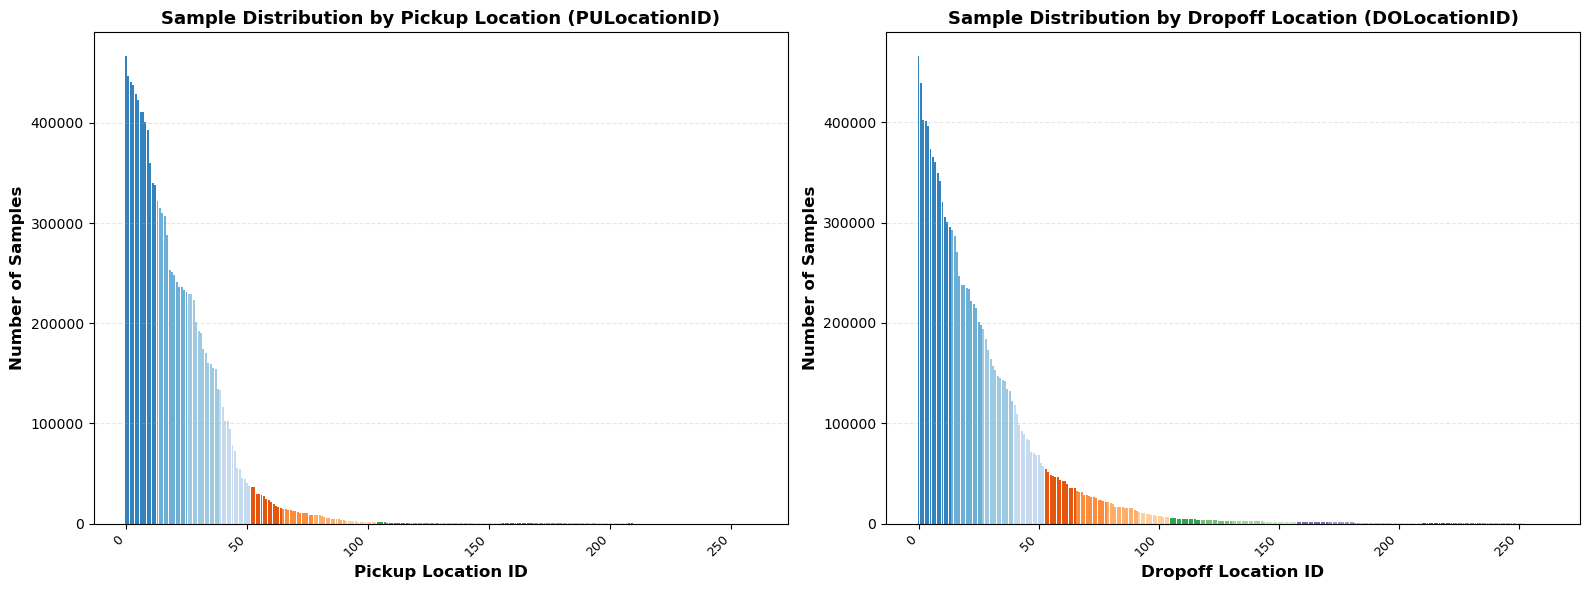


Class Distribution Summary:
  Total unique pickup locations: 261
  Total unique dropoff locations: 263

Top 5 Pickup Locations:
PULocationID
237.0    467133
161.0    446394
236.0    441389
79.0     437765
230.0    429252
Name: count, dtype: int64

Top 5 Dropoff Locations:
DOLocationID
161.0    466409
236.0    439571
237.0    402609
170.0    401250
230.0    396408
Name: count, dtype: int64


In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Plot class distribution by Location IDs
print("Computing class distribution...")
pu_counts = df_combined['PULocationID'].value_counts().compute().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for PULocationID
colors1 = plt.cm.tab20c(np.linspace(0, 1, len(pu_counts)))
ax1.bar(range(len(pu_counts)), pu_counts.values, color=colors1)
ax1.set_xlabel('Pickup Location ID', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Sample Distribution by Pickup Location (PULocationID)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

# Bar chart for DOLocationID
print("Computing dropoff location distribution...")
do_counts = df_combined['DOLocationID'].value_counts().compute().sort_values(ascending=False)
colors2 = plt.cm.tab20c(np.linspace(0, 1, len(do_counts)))
ax2.bar(range(len(do_counts)), do_counts.values, color=colors2)
ax2.set_xlabel('Dropoff Location ID', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax2.set_title('Sample Distribution by Dropoff Location (DOLocationID)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nClass Distribution Summary:")
print(f"  Total unique pickup locations: {len(pu_counts)}")
print(f"  Total unique dropoff locations: {len(do_counts)}")
print(f"\nTop 5 Pickup Locations:\n{pu_counts.head()}")
print(f"\nTop 5 Dropoff Locations:\n{do_counts.head()}")

In [97]:
print("Exporting to Parquet directory...")
RESULT_PARQUET_PATH = './data/combined_parquet/'
df_combined.to_parquet(RESULT_PARQUET_PATH, write_index=False)
print(f"Done! Saved under {RESULT_PARQUET_PATH} directory")


Exporting to Parquet directory...
Done! Saved under ./data/combined_parquet/ directory


In [98]:
# Below is deprecated
#print("Exporting to single CSV...")
#RESULT_CSV_PATH = './data/combined.csv'
#df_combined.to_csv(RESULT_CSV_PATH, single_file=True, index=False)
#print(f"Done. Saved as {RESULT_CSV_PATH}")